In [1]:
import numpy as np
import pandas as pd

import IPython.display as dp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
sns.despine()

plt.rc("figure", figsize=(12, 8))
plt.rc("font", size=13)

%matplotlib inline

<Figure size 640x480 with 0 Axes>

In [2]:
!pip install "u8darts[notorch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.8/344.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully un

In [3]:
!pip install astsadata

In [2]:
from darts import TimeSeries
import darts.datasets as ds
import scipy.stats as sts
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from darts.utils.statistics import plot_acf, plot_pacf, check_seasonality
import numpy as np
import pandas as pd

In [3]:
co2 = pd.read_csv(
    "https://raw.githubusercontent.com/statsmodels/smdatasets/refs/heads/main/data/stl-decomposition/co2.csv",
    parse_dates=True,
    index_col=0,
).iloc[:, 0]

In [4]:
co2_ts = TimeSeries.from_series(co2)

<Axes: xlabel='date'>

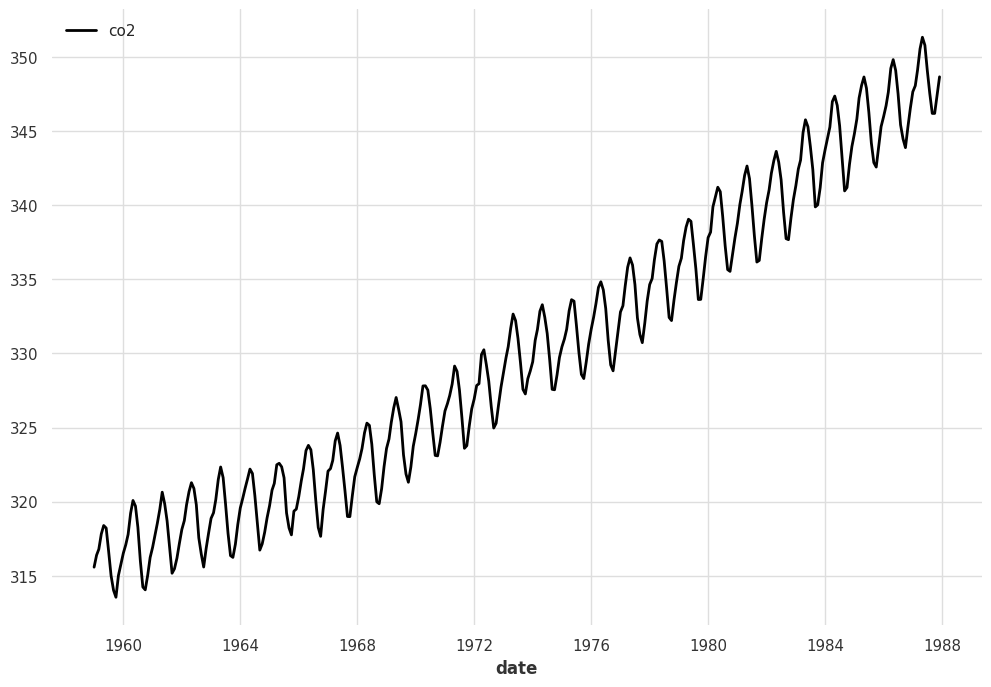

In [5]:
co2_ts.plot()

In [6]:
from darts.models import NaiveDrift, ExponentialSmoothing
from darts.utils.utils import ModelMode

In [7]:
train, val = co2_ts.split_before(pd.Timestamp("19850101"))

## ETS in darts

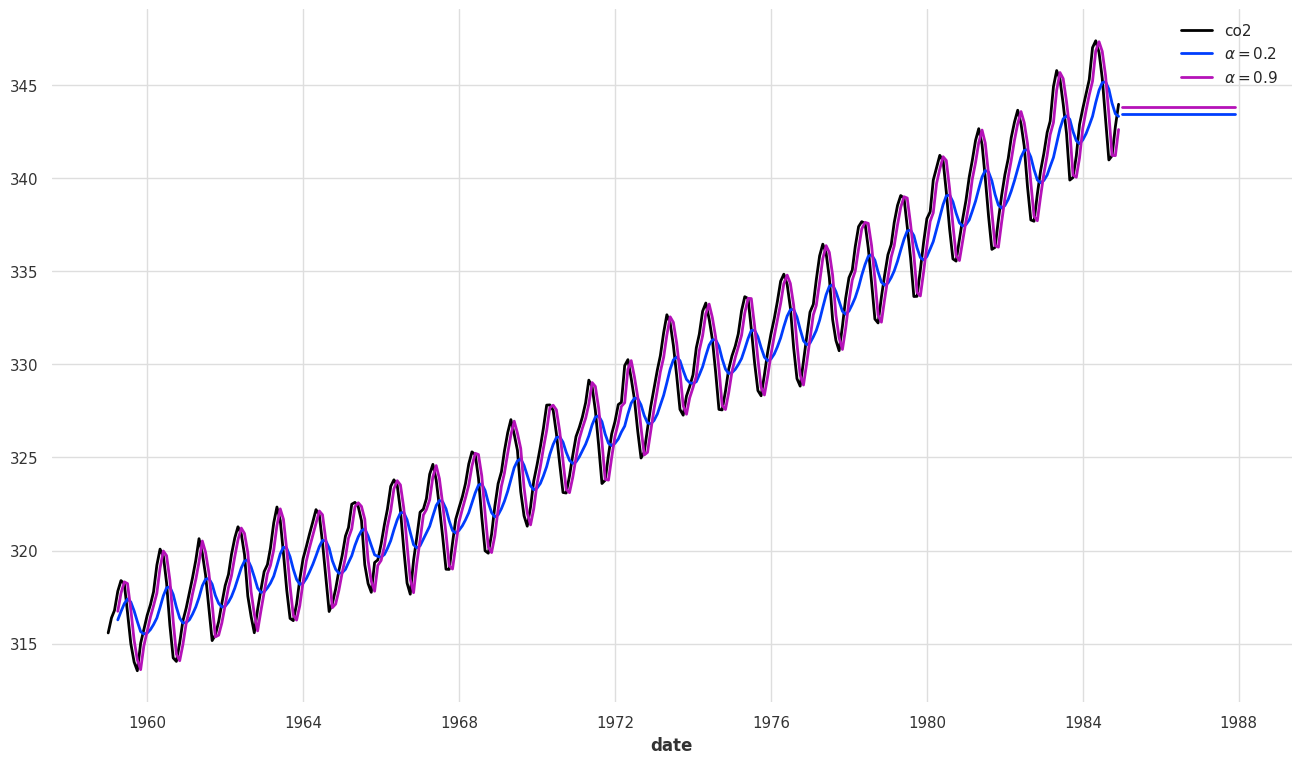

In [8]:
ses_02_bcast = ExponentialSmoothing(
    trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.2
).historical_forecasts(train)
ses_09_bcast = ExponentialSmoothing(
    trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.9
).historical_forecasts(train)

ses_02_fcast = ExponentialSmoothing(
    trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.2
    ).fit(train).predict(len(val))
ses_09_fcast = ExponentialSmoothing(
    trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.9
    ).fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
ses_02_bcast.plot(label="$\\alpha = 0.2$", color="C1", ax=ax);
ses_09_bcast.plot(label="$\\alpha = 0.9$", color="C2", ax=ax);
ses_02_fcast.plot(label=None, color="C1", ax=ax);
ses_09_fcast.plot(label=None, color="C2", ax=ax);

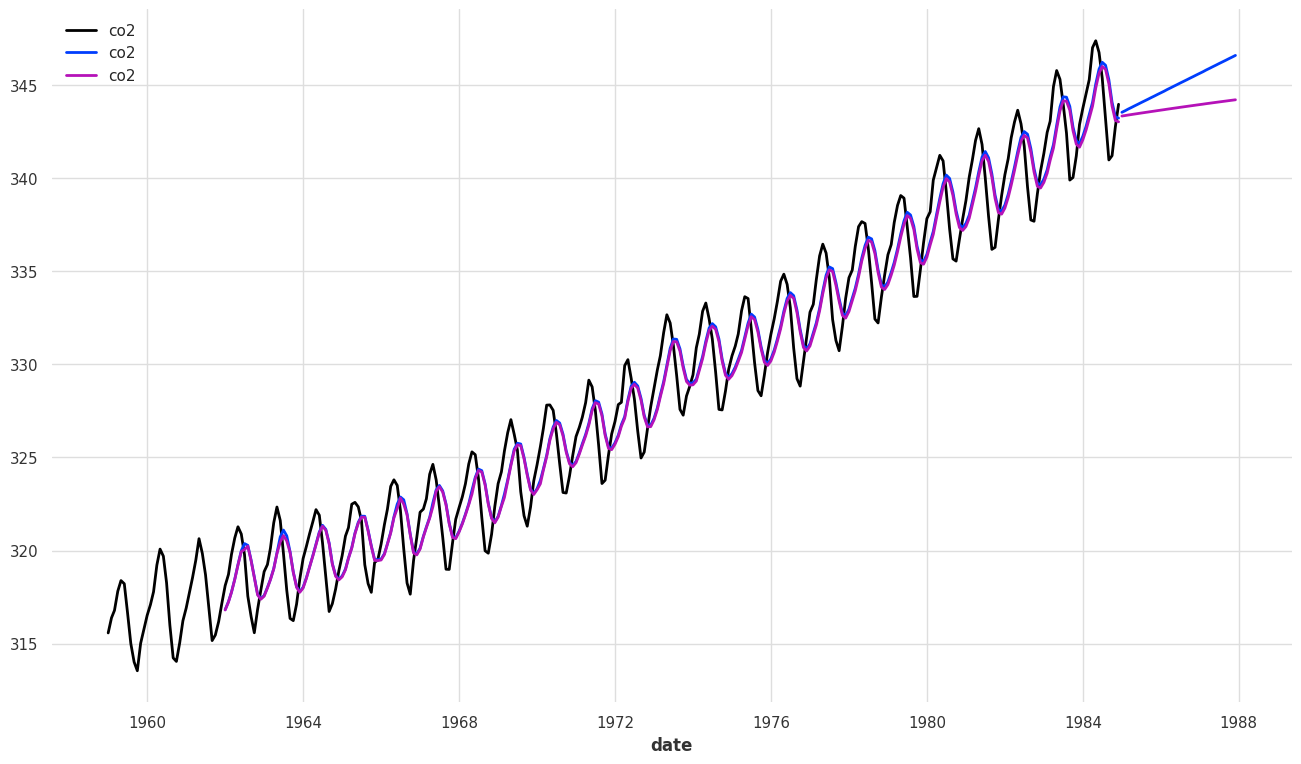

In [58]:
ets_bcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, seasonal_periods=12, smoothing_level=0.3
).historical_forecasts(train, start=36)
ets_damped_bcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, seasonal_periods=12, smoothing_level=0.3, damped=True
).historical_forecasts(train, start=36)

ets_fcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, seasonal_periods=12, smoothing_level=0.3
).fit(train).predict(len(val))
ets_damped_fcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, seasonal_periods=12, smoothing_level=0.3, damped=True
).fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
ets_bcast.plot(color="C1", ax=ax);
ets_damped_bcast.plot(color="C2", ax=ax);
ets_fcast.plot(label=None, color="C1", ax=ax);
ets_damped_fcast.plot(label=None, color="C2", ax=ax);

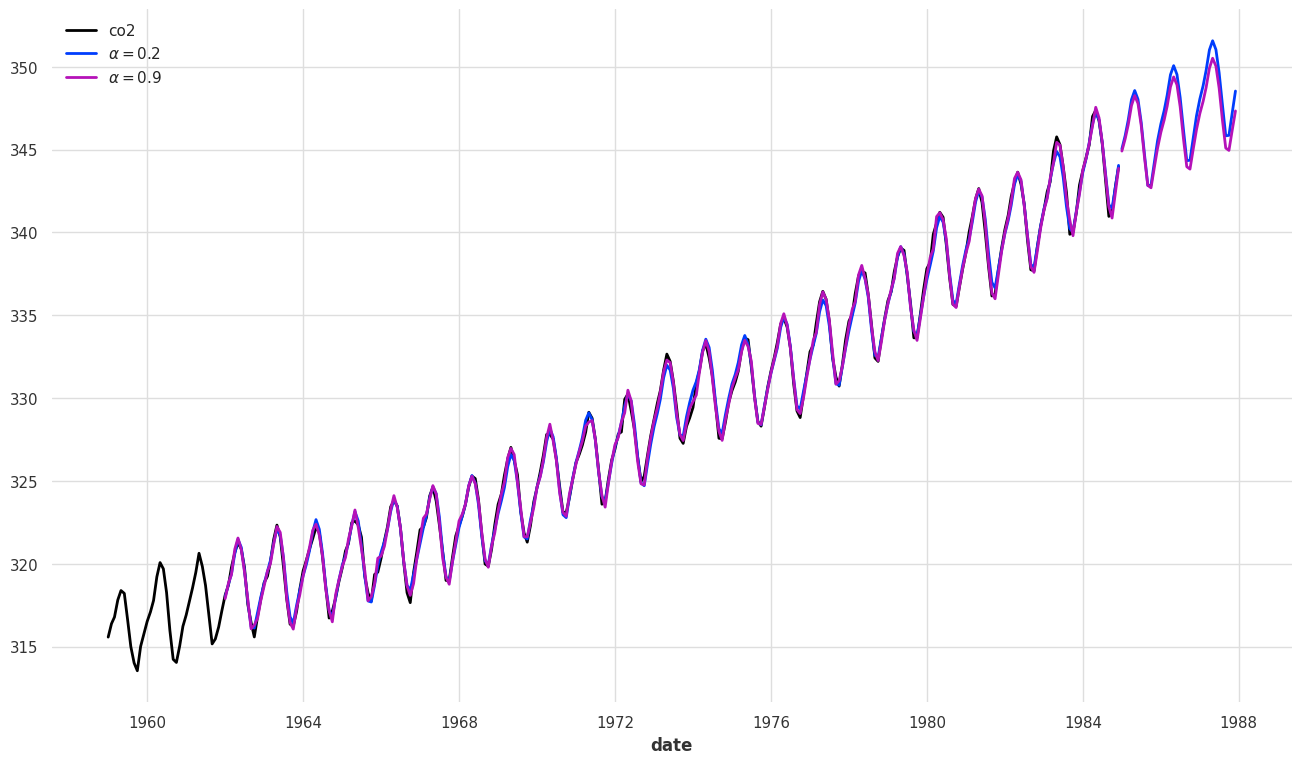

In [57]:
ets_02_bcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.ADDITIVE, seasonal_periods=12, smoothing_level=0.2,
).historical_forecasts(train, start=36)
ets_09_bcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.ADDITIVE, seasonal_periods=12, smoothing_level=0.9
).historical_forecasts(train, start=36)

ets_02_fcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.ADDITIVE, seasonal_periods=12, smoothing_level=0.2
).fit(train).predict(len(val))
ets_09_fcast = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, seasonal=ModelMode.ADDITIVE, seasonal_periods=12, smoothing_level=0.9
).fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
ets_02_bcast.plot(label="$\\alpha = 0.2$", color="C1", ax=ax);
ets_09_bcast.plot(label="$\\alpha = 0.9$", color="C2", ax=ax);
ets_02_fcast.plot(label=None, color="C1", ax=ax);
ets_09_fcast.plot(label=None, color="C2", ax=ax);

## Confidence intervals

In [10]:
from darts.models import NaiveMean, NaiveSeasonal, NaiveDrift

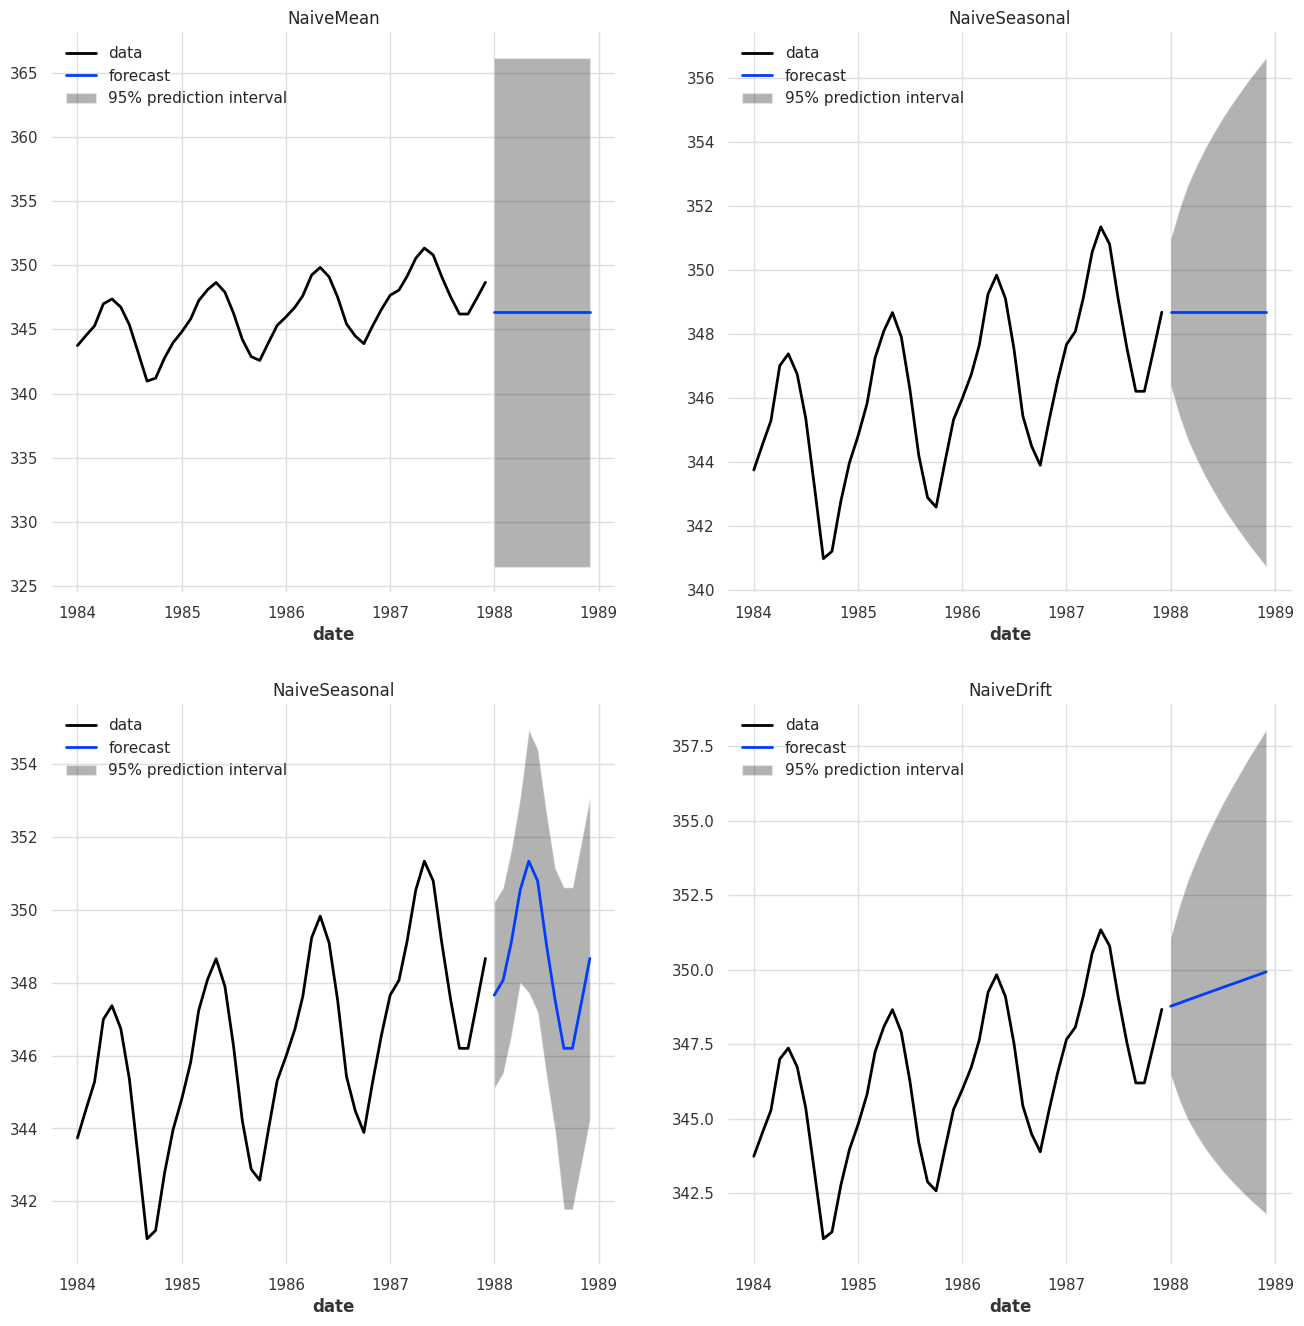

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for i, (model, ax) in enumerate(
    zip(
        [
            NaiveMean(),
            NaiveSeasonal(K=1),
            NaiveSeasonal(K=12),
            NaiveDrift(),
        ],
        axes.flatten()
    )
):
    co2_ts[-48:].plot(ax=ax, label="data");
    model.fit(co2_ts[-48:]);
    resid = model.residuals(co2_ts)
    sigma_hat = np.sqrt((resid.values() ** 2).sum() / len(resid))
    if i == 0:
        sigma_hat_hs = [sigma_hat * np.sqrt(1 + 1 / len(resid))] * 12
    elif i == 1:
        sigma_hat_hs = [sigma_hat * np.sqrt(h) for h in range(1, 13)]
    elif i == 2:
        sigma_hat_hs = [sigma_hat * np.sqrt(np.floor((h - 1) / 4) + 1) for h in range(1, 13)]
    elif i == 3:
        sigma_hat_hs = [sigma_hat * np.sqrt(h * (1 + h / (len(resid) + 1))) for h in range(1, 13)]
    fcast = model.predict(12)
    fcast.plot(ax=ax, label="forecast");
    lbs = [y - 1.96 * s for y, s in zip(fcast.values().flatten(), sigma_hat_hs)]
    ubs = [y + 1.96 * s for y, s in zip(fcast.values().flatten(), sigma_hat_hs)]
    ax.fill_between(fcast.to_series().index, lbs, ubs, alpha=0.3, label="95% prediction interval")
    ax.set_title(model.__class__.__name__)
    ax.legend();

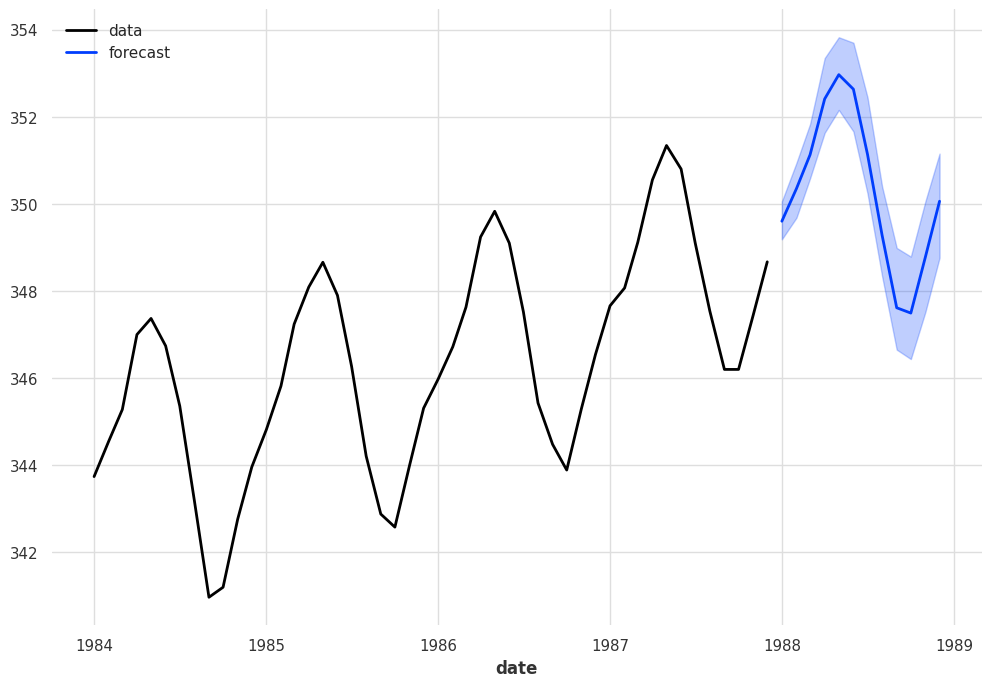

In [60]:
ets = ExponentialSmoothing()
ets.fit(co2_ts)
fcast = ets.predict(12, num_samples=50)
fig, ax = plt.subplots()
co2_ts[-48:].plot(ax=ax, label="data")
fcast.plot(ax=ax, label="forecast");

## GARCH

ARCH(m)
$$
y_t = \sigma_t \varepsilon_t, \varepsilon_t \sim \mathcal{N}(0, 1)
$$
$$
\sigma^2_t = \alpha_0 + \alpha_1 y_{t-1}^2 + \ldots + \alpha_m y_{t-m}^2
$$

$$
y_t^2 = (\alpha_0 + \alpha_1 y_{t-1}^2) \varepsilon_t^2
$$

$$
y_t^2 = \alpha_0 \varepsilon_t^2 + \alpha_1 y_{t-1}^2 \varepsilon_t^2
$$

GARCH(m, p)
$$
y_t = \sigma_t \varepsilon_t
$$
$$
\sigma^2_t = \alpha_0 + \alpha_1 y_{t-1}^2 + \ldots + \alpha_m y_{t-m}^2 + \beta_{t-1} \sigma^2_{t-1} + \ldots + \beta_{t-p} \sigma^2_{t-p}
$$

In [13]:
!pip install arch

In [14]:
from arch import arch_model

In [15]:
from astsadata import eqexp

/usr/local/lib/python3.12/dist-packages/astsadata/astsadata.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  birth = pd.read_csv(f"{path}/data/birth.csv", index_col=0, parse_dates=True)
/usr/local/lib/python3.12/dist-packages/astsadata/astsadata.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cardox = pd.read_csv(f"{path}/data/cardox.csv", index_col=0, parse_dates=True)
/usr/local/lib/python3.12/dist-packages/astsadata/astsadata.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chicken = pd.read_csv(f"{path}/data/chicken.csv", index_col=0, parse_dates=True)
/usr

In [16]:
exp6 = TimeSeries.from_series(eqexp["EX6"])
exp6 = exp6[0:70].map(lambda ts, x: x + 10)

In [17]:
returns = (exp6.diff(n=1) / exp6[:-1])

<Axes: xlabel='time'>

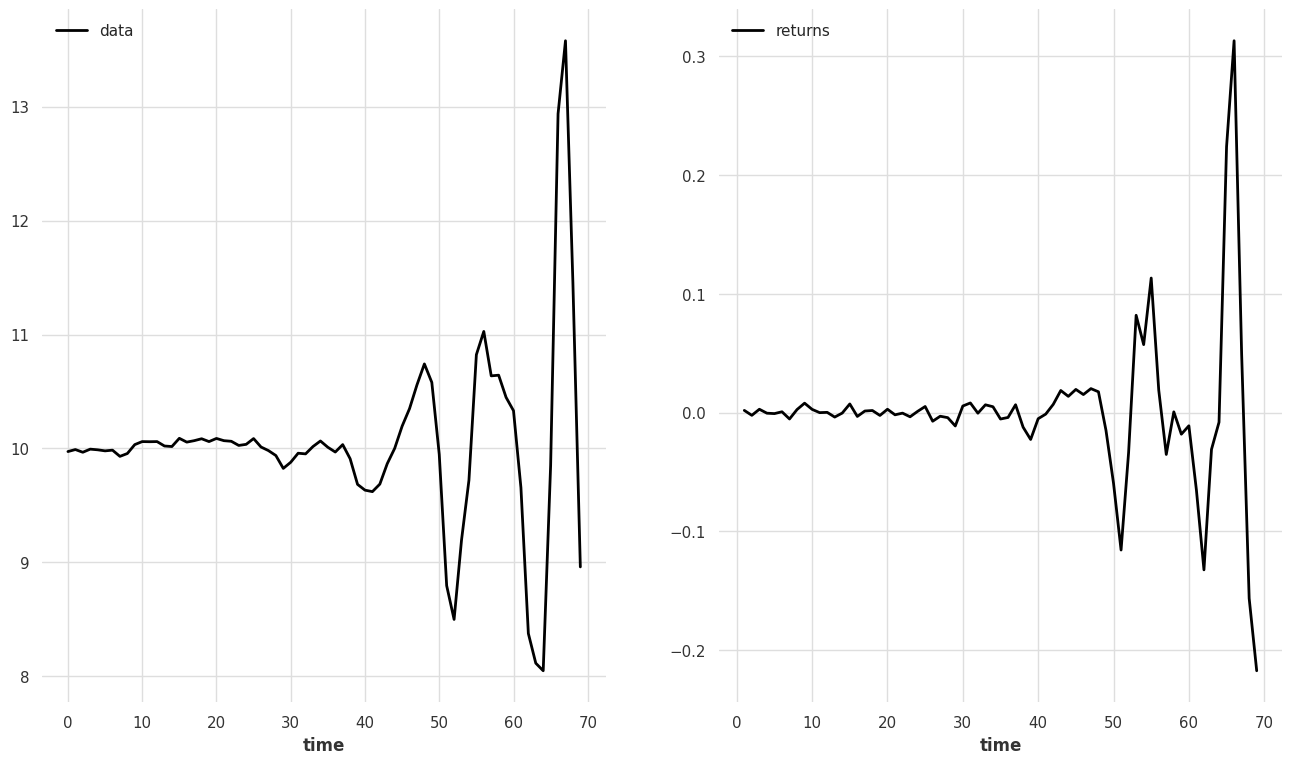

In [18]:
fig, ax = plt.subplots(1,2,figsize=(16,9))
exp6.plot(ax=ax[0], label="data")
returns.plot(ax=ax[1], label="returns")

In [19]:
returns = returns.values().flatten()

In [20]:
garch = arch_model(returns, p=1, q=1, rescale=False)
garch_fitted = garch.fit()
garch_forecast = garch_fitted.forecast(horizon=100)

Iteration:      1,   Func. Count:      5,   Neg. LLF: -148.46330696307564
Optimization terminated successfully    (Exit mode 0)
            Current function value: -148.46330729426734
            Iterations: 5
            Function evaluations: 5
            Gradient evaluations: 1


In [21]:
fcast = garch_forecast.mean.values[0]
sigma_hat_hs = np.sqrt(garch_forecast.variance.values[0])

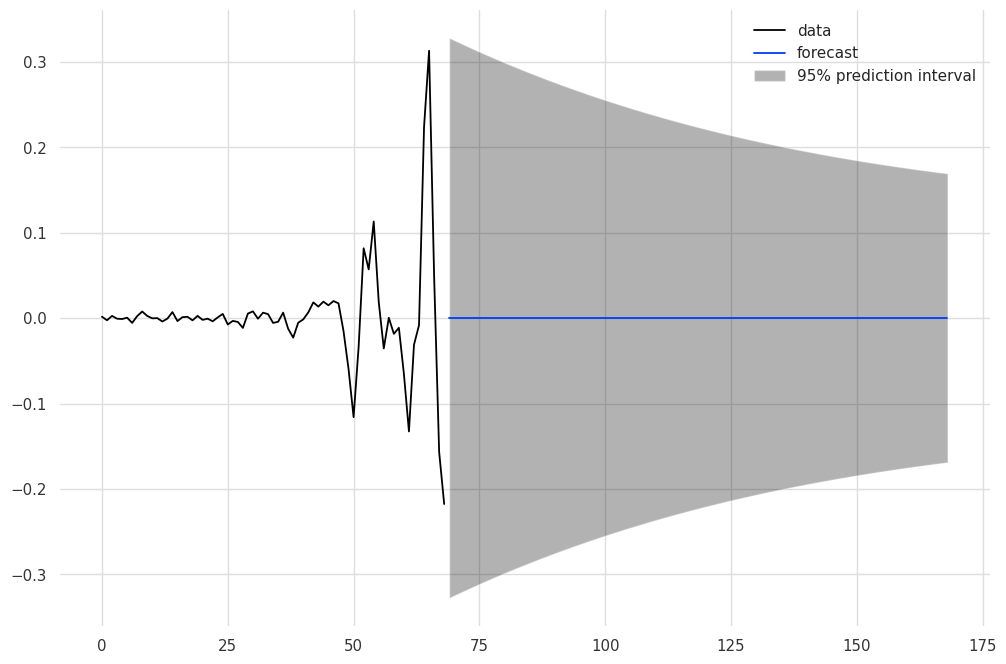

In [22]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(returns)), returns, label="data")
ax.plot(np.arange(len(returns), len(returns)+100), fcast, label="forecast");
lbs = [y - 1.96 * s for y, s in zip(fcast, sigma_hat_hs)]
ubs = [y + 1.96 * s for y, s in zip(fcast, sigma_hat_hs)]
ax.fill_between(np.arange(len(returns), len(returns)+100), lbs, ubs, alpha=0.3, label="95% prediction interval")
ax.legend();

In [23]:
from astsadata import UnempRate

In [24]:
from datetime import date

In [25]:
UnempRate = UnempRate.set_axis(
    pd.date_range(
      date(UnempRate.index[0].year, UnempRate.index[0].month, 1),
      date(UnempRate.index[-1].year, UnempRate.index[-1].month, 1),
      freq="MS"
  ),
  axis=0
)
unemp_rate = TimeSeries.from_dataframe(UnempRate)

In [26]:
unemp_rate_part = unemp_rate[pd.Timestamp("19900101"):pd.Timestamp("20100101")]

In [27]:
returns = (unemp_rate_part.diff(n=1) / unemp_rate_part[:-1])

<Axes: xlabel='time'>

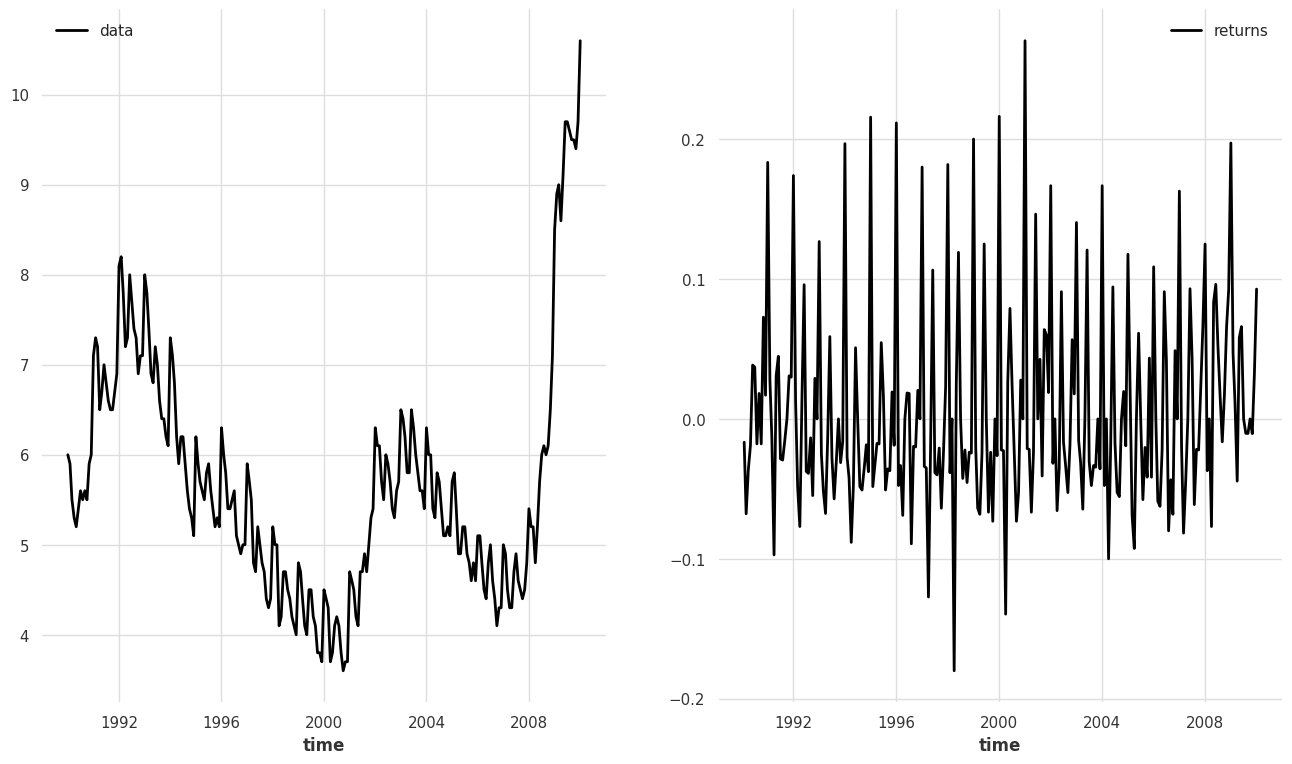

In [28]:
fig, ax = plt.subplots(1,2,figsize=(16,9))
unemp_rate_part.plot(ax=ax[0], label="data")
returns.plot(ax=ax[1], label="returns")

In [29]:
returns = returns.values().flatten()

In [30]:
garch = arch_model(returns, p=12, q=3, rescale=False)
garch_fitted = garch.fit()
garch_forecast = garch_fitted.forecast(horizon=100)

Iteration:      1,   Func. Count:     19,   Neg. LLF: 32189.515850976353
Iteration:      2,   Func. Count:     42,   Neg. LLF: 388.94007453718007
Iteration:      3,   Func. Count:     64,   Neg. LLF: 2197.4181447089522
Iteration:      4,   Func. Count:     83,   Neg. LLF: 28481.738262778512
Iteration:      5,   Func. Count:    102,   Neg. LLF: 25.01200719158612
Iteration:      6,   Func. Count:    121,   Neg. LLF: 13021.44906418063
Iteration:      7,   Func. Count:    140,   Neg. LLF: -262.36777419369315
Iteration:      8,   Func. Count:    159,   Neg. LLF: 1447.8335160886231
Iteration:      9,   Func. Count:    178,   Neg. LLF: -247.69279233617434
Iteration:     10,   Func. Count:    197,   Neg. LLF: 844.3814907738682
Iteration:     11,   Func. Count:    216,   Neg. LLF: 1907.7370135321082
Iteration:     12,   Func. Count:    235,   Neg. LLF: -243.26976366316399
Iteration:     13,   Func. Count:    254,   Neg. LLF: -160.89476562452165
Iteration:     14,   Func. Count:    273,   Neg. L

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [31]:
fcast = garch_forecast.mean.values[0]
sigma_hat_hs = np.sqrt(garch_forecast.variance.values[0])

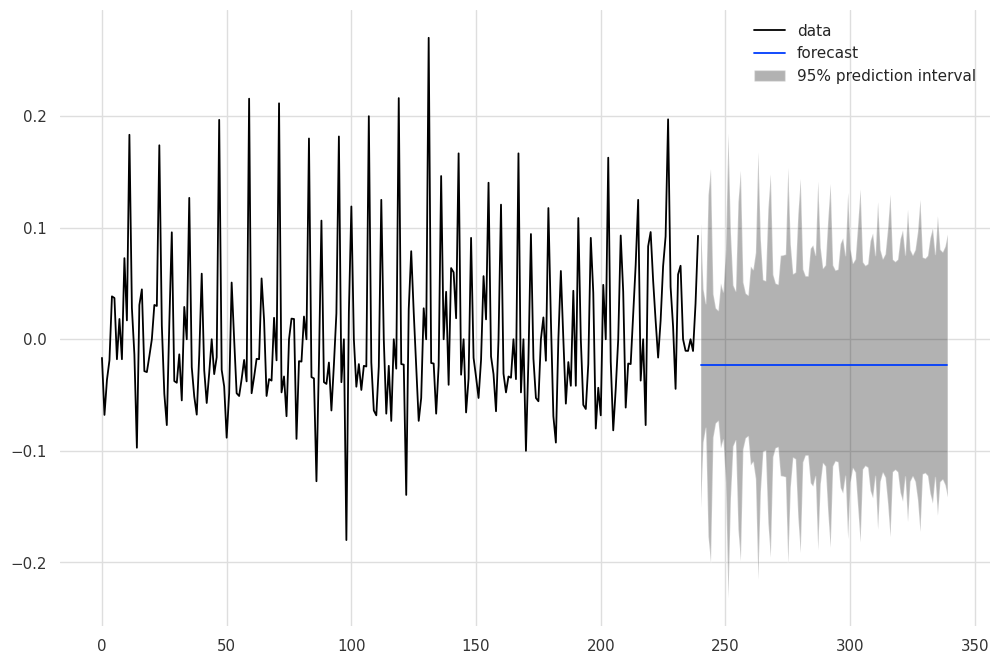

In [32]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(returns)), returns, label="data")
ax.plot(np.arange(len(returns), len(returns)+100), fcast, label="forecast");
lbs = [y - 1.96 * s for y, s in zip(fcast, sigma_hat_hs)]
ubs = [y + 1.96 * s for y, s in zip(fcast, sigma_hat_hs)]
ax.fill_between(np.arange(len(returns), len(returns)+100), lbs, ubs, alpha=0.3, label="95% prediction interval")
ax.legend();

## AutoETS

In [33]:
from darts.models import AutoETS

In [34]:
auto_ets = AutoETS(season_length=12)
auto_ets.fit(train)

AutoETS(add_encoders=None, quantiles=None, random_state=None, season_length=12)

In [35]:
auto_fcast = auto_ets.predict(len(val))

In [36]:
auto_ets.model.model_["method"]

'ETS(M,A,A)'

<Axes: xlabel='date'>

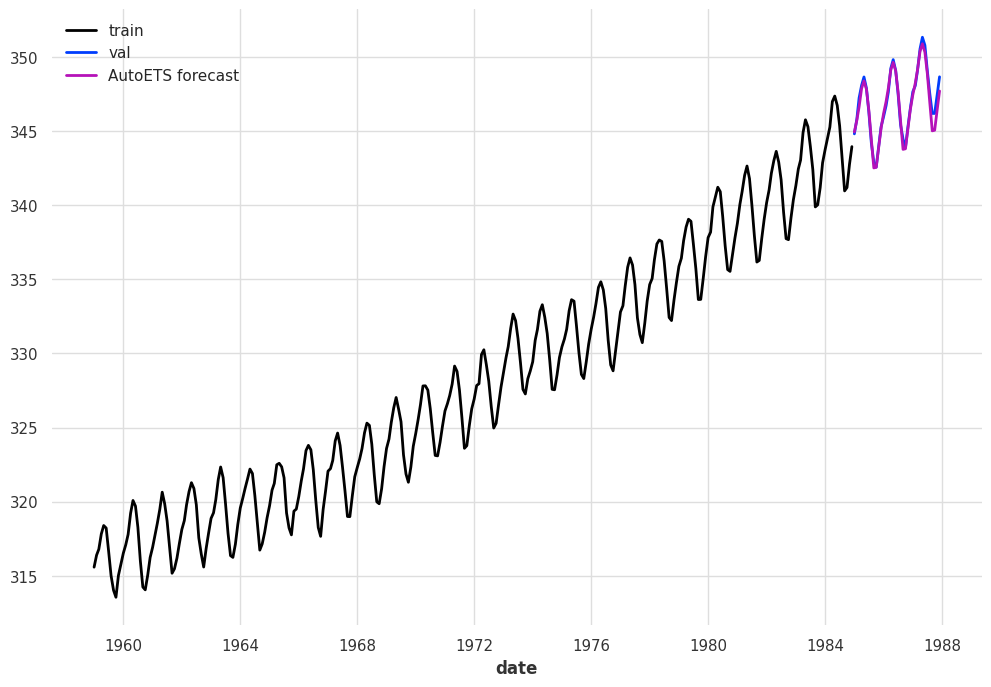

In [62]:
train.plot(label="train")
val.plot(label="val")
auto_fcast.plot(label="AutoETS forecast")

## Quality measures

- MSE
  $$
  MSE=\frac{1}{T-R+1} \sum_{t=R}^T\left(\hat{x}_t-x_t\right)^2
  $$
- MAE
  $$
  MAE=\frac{1}{T-R+1} \sum_{t=R}^T\left|\hat{x}_t-x_t\right|.
  $$
- MAPE
  $$
  MAPE=\frac{100}{T-R+1} \sum_{t=R}^T\left|\frac{\hat{x}_t-x_t}{x_t}\right|.
  $$
- SMAPE
  $$
  SMAPE=\frac{200}{T-R+1} \sum_{t=R}^T\left|\frac{\hat{x}_t-x_t}{\hat{x}_t+x_t}\right|.
  $$
- MASE
  $$
  MASE=\frac{1}{T-R+1} \sum_{t=R}^T\left|\hat{x}_t-x_t\right| \big/ \frac{1}{T-1} \sum_{t=2}^T\left|x_t-x_{t-1}\right|.
  $$

## Non-linear models

In [38]:
from astsadata import gtemp

In [40]:
gtemp = TimeSeries.from_dataframe(gtemp.set_index(
    pd.date_range(
        pd.to_datetime(f"{gtemp.index.min().year}-12-31").date(),
        pd.to_datetime(f"{gtemp.index.max().year}-12-31").date(),
        freq="Y",
    )
))

/tmp/ipython-input-2914116456.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  pd.date_range(


<Axes: xlabel='time'>

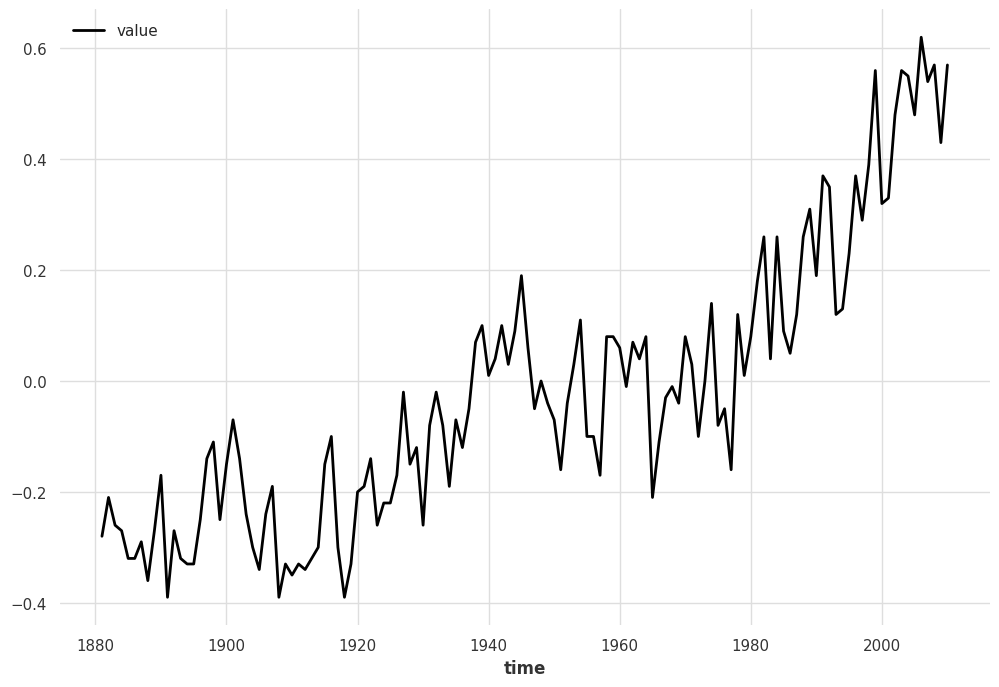

In [41]:
gtemp.plot()

In [42]:
changepoint = pd.Timestamp("19660101")

ts1, ts2 = gtemp.split_before(changepoint)

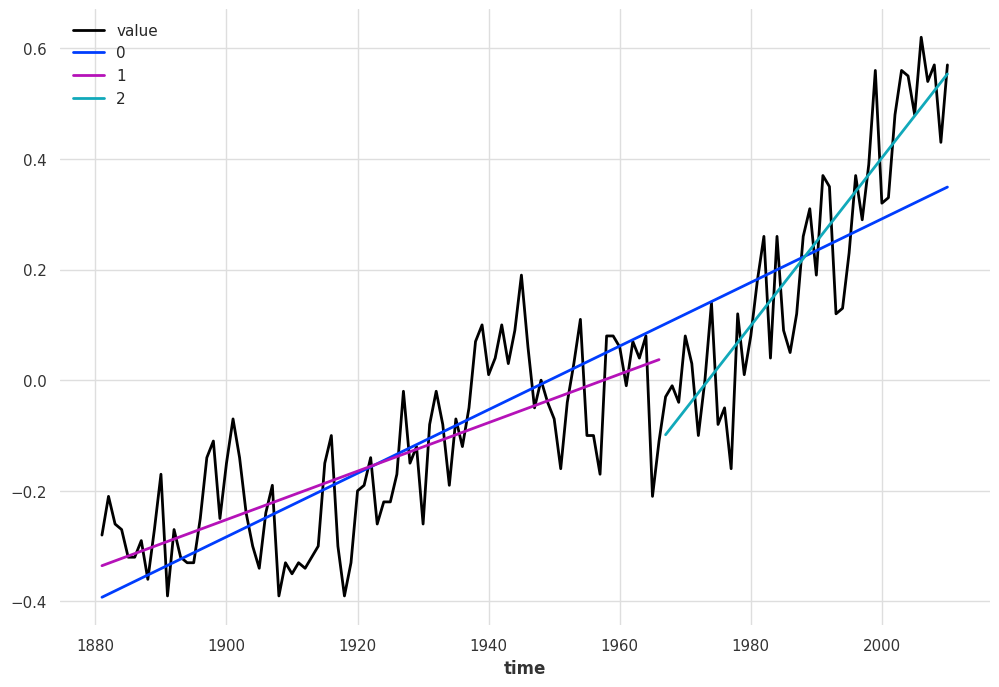

In [44]:
ets0 = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, smoothing_level=1e-8).fit(gtemp)
fcast0 = TimeSeries.from_series(pd.Series(ets0.model.fittedvalues, index=gtemp.to_series().index))
ets1 = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, smoothing_level=1e-8).fit(ts1)
fcast1 = TimeSeries.from_series(pd.Series(ets1.model.fittedvalues, index=ts1.to_series().index))
ets2 = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, smoothing_level=1e-8).fit(ts2)
fcast2 = TimeSeries.from_series(pd.Series(ets2.model.fittedvalues, index=ts2.to_series().index))
gtemp.plot();
fcast0.plot(label="0");
fcast1.plot(label="1");
fcast2.plot(label="2");

In [45]:
from darts.metrics.metrics import mse

In [46]:
mse([gtemp, gtemp], [fcast0, fcast1.append(fcast2)])

[np.float64(0.015421287589241627), np.float64(0.009817328388459477)]

## Testing for structural change

For one changepoint, there is Chow test. Let $r_{t0}, r_{1t}, r_{2t}$ be the residuals of combined model and two separate models respectively, $k_0, k_{1}, k_{2}$ their parameter counts, then
$$
F = \frac{(RSS_0 - RSS_1 - RSS_2) / (k_1 + k_2 - k)}{(RSS_1 + RSS_2) / (n - k_1 - k_2)} \sim F(k_1 + k_2 - k, n - k_1 - k_2)
$$
where $RSS_i = \sum r_{it}^2$.

In [47]:
resid0 = gtemp[fcast0.start_time():] - fcast0
k0 = ets0.model.k
rss0 = np.sum(ets0.model.resid ** 2)

resid1 = gtemp[fcast1.start_time():fcast1.end_time()] - fcast1
k1 = ets1.model.k
rss1 = np.sum(ets1.model.resid ** 2)

resid2 = gtemp[fcast2.start_time():fcast2.end_time()] - fcast2
k2 = ets2.model.k
rss2 = np.sum(ets2.model.resid ** 2)

stat = ((rss0 - rss1 - rss2) / (k1 + k2 - k0)) / ((rss1 - rss2) / (len(ets0.model.resid) - k1 - k2))

pvalue = sts.f(k1 + k2 - k0, len(ets0.model.resid) - k1 - k2).sf(stat)

print("rejected" if pvalue < 0.05 else "not rejected")

rejected


## Complex seasonalities

- Models we've considered are suitable for rather short seasonal periods, like 2 or 4. If we want to model yearly seasonality in daily data, this would result in too many parameters.
- Also higher frequency time series often exhibit more multiple seasonal patterns.
- 52.18 of weeks in a year, 365.25 days in a year

## Complex seasonalities

Solution:
- Model catches only the shortest seasonality
- Other seasonalities are modeled using regression onto Fourier series (sin and cos with respective periods):
  $$
    \sin \left( \frac{2 \pi k t}{S} \right), \; \cos \left( \frac{2 \pi k t}{S} \right), k = 1, 2, \ldots, K
  $$

In [48]:
from darts.utils.timeseries_generation import sine_timeseries
from darts import concatenate
from darts.models import ARIMA

In [49]:
from astsadata import part

In [53]:
part = TimeSeries.from_dataframe(part.set_index(
    pd.date_range(
        part.index[0].start_time.date(),
        periods=len(part),
        freq="W-MON",
        inclusive="both"
    )
))

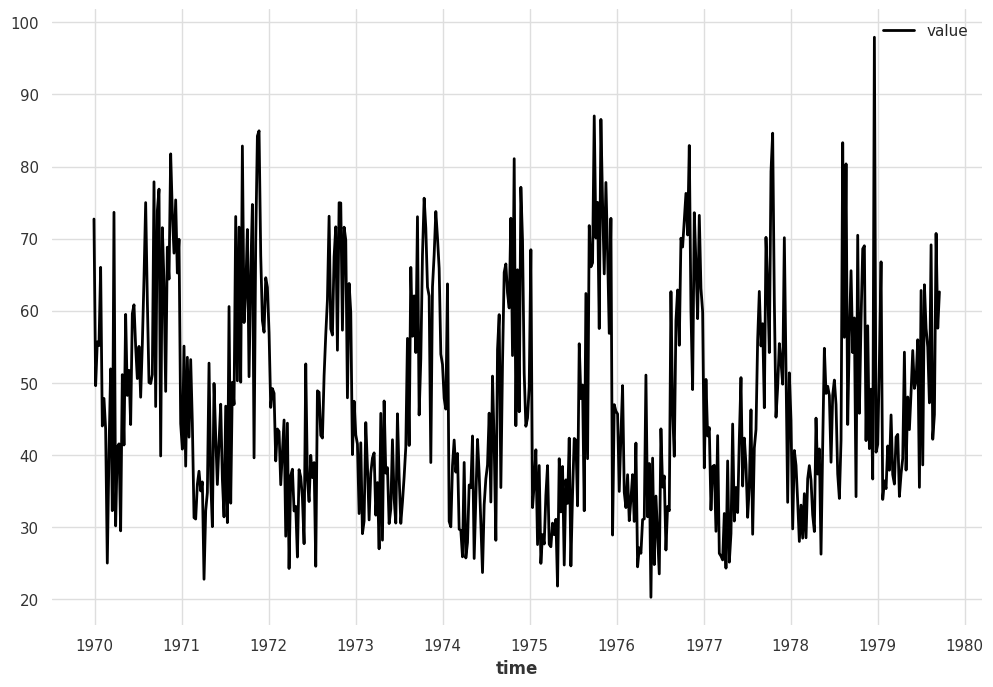

In [54]:
part.plot();

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


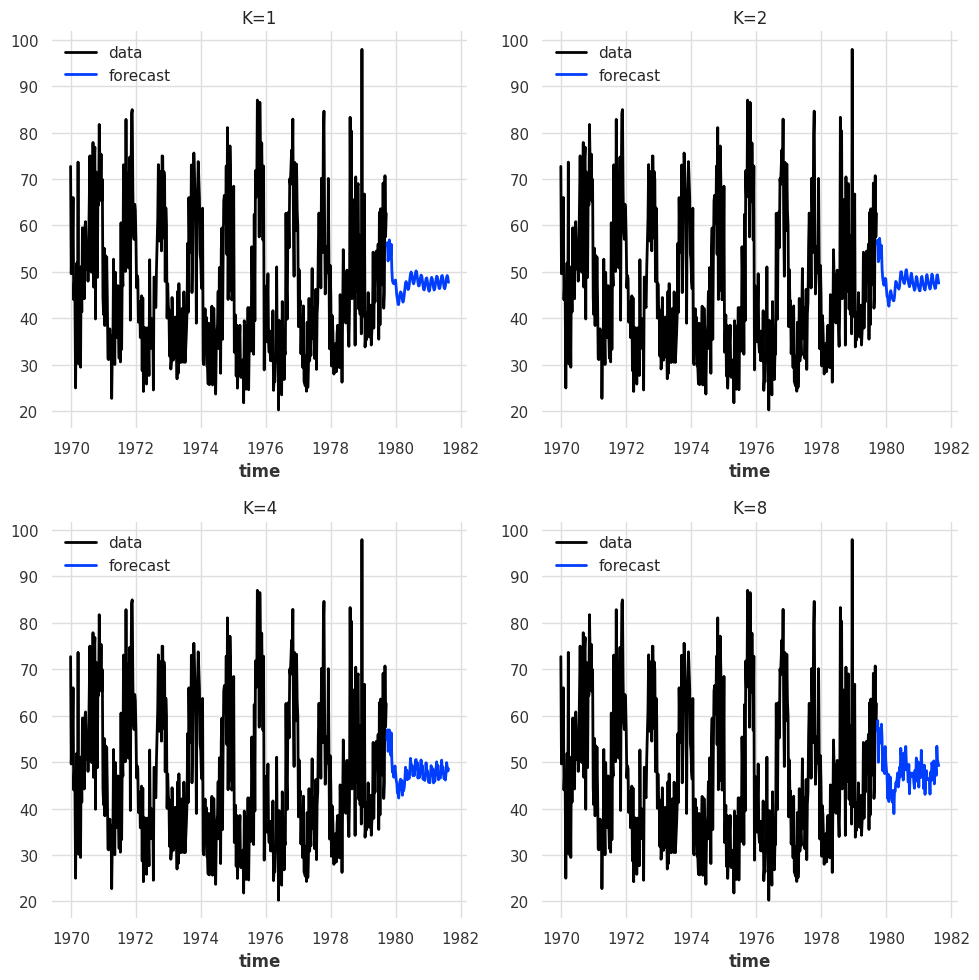

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, K in zip(axes.flatten(), [1, 2, 4, 8]):
    harmonics = concatenate([
        sine_timeseries(value_frequency=2 * np.pi * k / 52.18, start=part.start_time(), length=len(part) + 100, freq="W-MON")
        for k in range(1, K + 1)
    ] + [
        sine_timeseries(value_frequency=2 * np.pi * k / 52.18, value_phase=np.pi / 2, start=part.start_time(), length=len(part)+100, freq="W-MON")
        for k in range(1, K + 1)
    ], axis="component")

    arima = ARIMA(12, 0, 0)
    arima.fit(part, future_covariates=harmonics)
    fcast = arima.predict(100, future_covariates=harmonics)
    part.plot(label="data", ax=ax)
    fcast.plot(label="forecast", ax=ax)
    ax.set_title(f"{K=}")
plt.tight_layout()

In [63]:
harmonics.to_dataframe()

,sine,sine_1,sine_2,sine_3,sine_4,sine_5,sine_6,sine_7,sine_8,sine_9,sine_10,sine_11,sine_12,sine_13,sine_14,sine_15
time,,,,,,,,,,,,,,,,
1969-12-29,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1970-01-05,0.686440,0.998340,0.765520,0.115012,-0.598249,-0.985090,-0.834440,-0.228498,0.727187,0.057602,-0.643413,-0.993364,-0.801310,-0.172040,0.551099,0.973544
1970-01-12,0.998340,0.115012,-0.985090,-0.228498,0.958766,0.338950,-0.919718,-0.444905,0.057602,-0.993364,-0.172040,0.973544,0.284196,-0.940804,-0.392580,0.895578
1970-01-19,0.765520,-0.985090,0.502119,0.338950,-0.938289,0.868464,-0.179272,-0.637772,-0.643413,-0.172040,0.864799,-0.940804,0.345852,0.495753,-0.983800,0.770225
1970-01-26,0.115012,-0.228498,0.338950,-0.444905,0.544955,-0.637772,0.722125,-0.796894,-0.993364,0.973544,-0.940804,0.895578,-0.838465,0.770225,-0.691763,0.604119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1981-07-20,-0.634724,0.980952,-0.881316,0.381102,0.292331,-0.832893,0.994887,-0.704683,-0.772739,0.194251,0.472528,-0.924533,0.956317,-0.553434,-0.100997,0.709523
1981-07-27,-0.992001,0.250433,0.928779,-0.484905,-0.806364,0.688474,0.632557,-0.848164,-0.126226,-0.968134,0.370634,0.874567,-0.591420,-0.725261,0.774514,0.529734
1981-08-03,-0.808017,-0.952101,-0.313861,0.582273,0.999964,0.596002,-0.297684,-0.946768,0.589159,-0.305783,-0.949469,-0.812993,-0.008496,0.802983,0.954665,0.321916


<Axes: xlabel='time'>

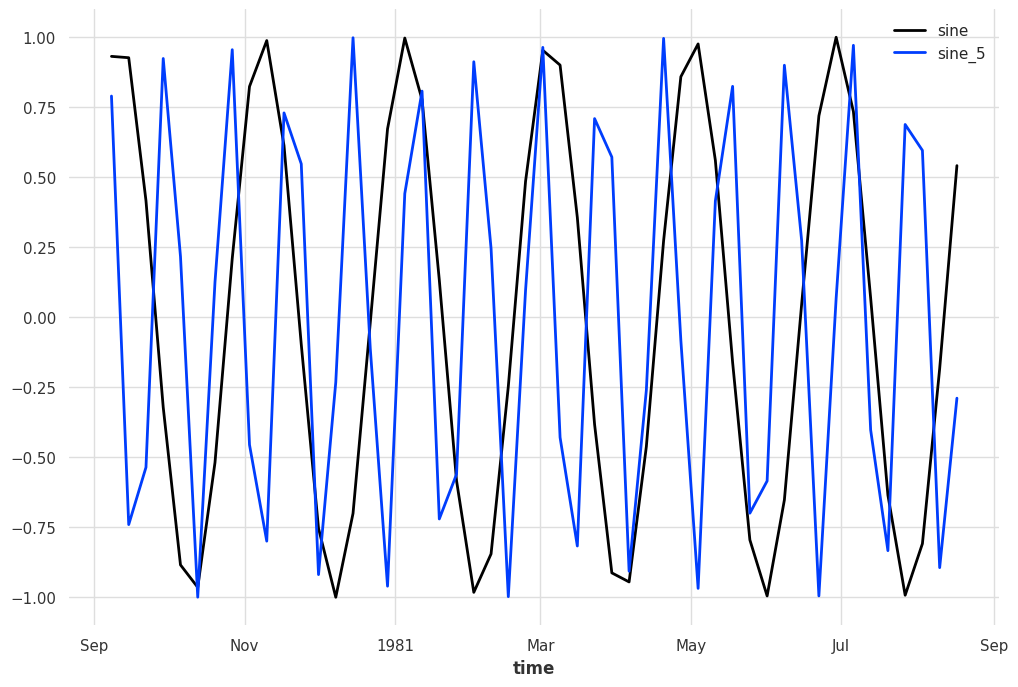

In [64]:
harmonics[["sine", "sine_5"]][-50:].plot()

In [65]:
from darts.models import Prophet

In [ ]:
prophet = Prophet(suppress_stdout_stderror=True)
prophet.add_seasonality("quarterly", seasonal_periods=4, fourier_order=2)
bcast = prophet.historical_forecasts(gtemp)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc_h5bs18/inz47uwx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc_h5bs18/jglt85b3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99706', 'data', 'file=/tmp/tmpc_h5bs18/inz47uwx.json', 'init=/tmp/tmpc_h5bs18/jglt85b3.json', 'output', 'file=/tmp/tmpc_h5bs18/prophet_modelw2k0vqu0/prophet_model-20251009122301.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
12:23:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:23:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

In [ ]:
prophet = Prophet(suppress_stdout_stderror=True)
prophet.add_seasonality("quarterly", seasonal_periods=4, fourier_order=2)
prophet.fit(gtemp)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc_h5bs18/2wvcfqq0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc_h5bs18/n2sharcw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93593', 'data', 'file=/tmp/tmpc_h5bs18/2wvcfqq0.json', 'init=/tmp/tmpc_h5bs18/n2sharcw.json', 'output', 'file=/tmp/tmpc_h5bs18/prophet_modelqqc9k7oa/prophet_model-20251009122415.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:24:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:24:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet(add_seasonalities=None, add_regressor_configs=None, country_holidays=None, cap=None, floor=None, add_encoders=None, random_state=None, suppress_stdout_stderror=True)

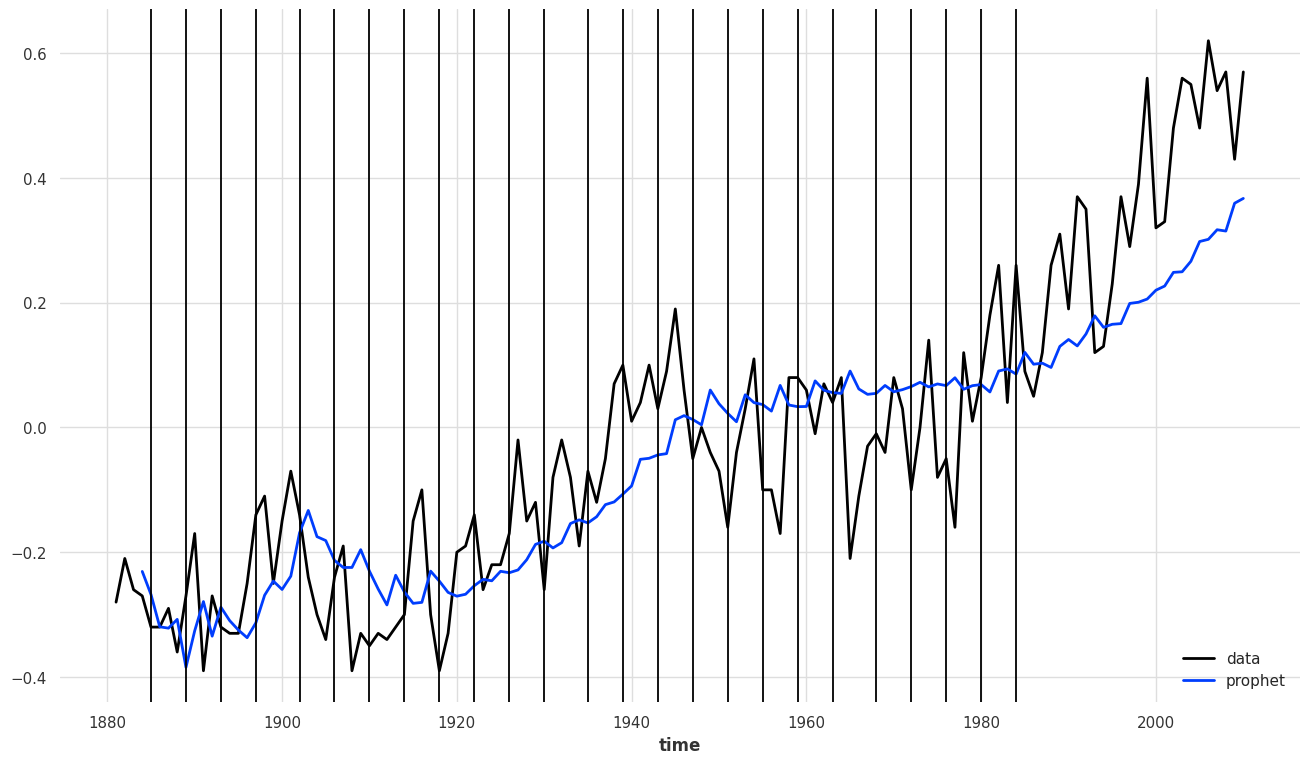

In [ ]:
fig, ax = plt.subplots(figsize=(16,9))
gtemp.plot(label="data", ax=ax);
bcast.plot(label="prophet", ax=ax);
[ax.axvline(x, 0, 1) for x in prophet.model.changepoints.values];

## ARIMA vs ETS vs Prophet

In [ ]:
from darts.models import AutoARIMA, AutoETS
from darts.datasets import AirPassengersDataset

In [ ]:
air_pax = AirPassengersDataset().load().map(lambda ts, x: np.log(x))

In [ ]:
train, test = air_pax.split_before(pd.Timestamp("19580101"))

In [ ]:
prophet = Prophet(suppress_stdout_stderror=True)
arima = AutoARIMA(season_length=12)
ets = AutoETS(season_length=12, model="ZZA")
prophet_fcast = prophet.fit(train).predict(len(test), num_samples=50)
arima_fcast = arima.fit(train).predict(len(test), num_samples=50)
ets_fcast = ets.fit(train).predict(len(test), num_samples=50)

In [ ]:
fig, ax = plt.subplots(figsize=(16,9))
# train.plot(label="train", ax=ax);
test.plot(label="test", ax=ax);
prophet_fcast.plot(label="prophet", ax=ax);
arima_fcast.plot(label="arima", ax=ax);
ets_fcast.plot(label="ets", ax=ax);

In [ ]:
from darts.metrics.metrics import mse

In [ ]:
mse([test, test, test], [prophet_fcast, arima_fcast, ets_fcast])

## Combining forecasts

In [ ]:
prophet = Prophet(suppress_stdout_stderror=True)
arima = AutoARIMA(season_length=12)
ets = AutoETS(season_length=12, model="ZZA")
prophet_fcast = prophet.fit(train).predict(len(test))
arima_fcast = arima.fit(train).predict(len(test))
ets_fcast = ets.fit(train).predict(len(test))
train[pd.Timestamp("19560101"):].plot(label="train");
test.plot(lw=4, label="test");
prophet_fcast.plot(lw=1, label="prophet");
arima_fcast.plot(lw=1, label="arima");
ets_fcast.plot(lw=1, label="ets");

## Combining forecasts

The idea is to use better models when possible via switching mechanism. This can be achieved with a linear combination of different forecasts, where the weights are dynamic and adaptively selected according to certain procedures. There are more ways to combine forecasts, e.g. to regress the series onto kPCA decomposition of forecasts.

Forecast combination puzzle: relative gain of complex methods compared to simple averaging is small and in most cases statistically insignificant.

In [ ]:
prophet = Prophet(suppress_stdout_stderror=True)
arima = AutoARIMA(season_length=12)
ets = AutoETS(season_length=12, model="ZZA")
prophet_fcast = prophet.fit(train).predict(len(test))
arima_fcast = arima.fit(train).predict(len(test))
ets_fcast = ets.fit(train).predict(len(test))
mean_fcast = concatenate([prophet_fcast, arima_fcast, ets_fcast], axis="component").mean(axis=1)
train[pd.Timestamp("19560101"):].plot(label="train");
test.plot(label="test");
prophet_fcast.plot(label="prophet");
arima_fcast.plot(label="arima");
ets_fcast.plot(label="ets");
mean_fcast.plot(label="average");

In [ ]:
mse([test, test, test, test], [prophet_fcast, arima_fcast, ets_fcast, mean_fcast])

## Forecasting hierarchical time series

We often want to forecast multiple time series that have hierarchical structure, e.g. sales grouped by store, country. The problem is to make the forecasts agree, e.g. so that sales in stores of a country sum to the sales in this country.

In [ ]:
from darts.datasets import AustralianTourismDataset

In [ ]:
tourism = AustralianTourismDataset().load()

In [ ]:
tourism.pd_dataframe().head()

In [ ]:
tourism[["Total", "NSW", "NSW - bus", "NSW - hol", "NSW - bus - city"]].plot();

In [ ]:
reasons = ["Hol", "VFR", "Bus", "Oth"]
regions = ["NSW", "VIC", "QLD", "SA", "WA", "TAS", "NT"]
city_labels = ["city", "noncity"]

In [ ]:
from itertools import product

In [ ]:
hierarchy = dict()

# Fill in grouping by reason
for reason in reasons:
    hierarchy[reason] = ["Total"]

# Fill in grouping by region
for region in regions:
    hierarchy[region] = ["Total"]

# Fill in grouping by (region, reason)
for region, reason in product(regions, reasons):
    hierarchy["{} - {}".format(region, reason.lower())] = [reason, region]

# Fill in grouping by (region, reason, <city>)
for region, reason, city in product(regions, reasons, city_labels):
    hierarchy["{} - {} - {}".format(region, reason.lower(), city)] = [
        "{} - {}".format(region, reason.lower())
    ]

In [ ]:
tourism = tourism.with_hierarchy(hierarchy)

In [ ]:
train, val = tourism[:-12], tourism[-12:]

In [ ]:
from darts.models import LinearRegressionModel

In [ ]:
model = LinearRegressionModel(lags=12)
model.fit(train)
pred = model.predict(n=len(val))

In [ ]:
components_to_show = ["Total", "NSW", "NSW - bus", "NSW - hol", "NSW - bus - city"]
plt.figure(figsize=(16, 9))
tourism[components_to_show].plot(lw=4)
pred[components_to_show].plot(lw=1);

In [ ]:
regions_reasons_comps = list(
    map(lambda t: "{} - {}".format(t[0], t[1].lower()), product(regions, reasons))
)

regions_reasons_city_comps = list(
    map(
        lambda t: "{} - {} - {}".format(t[0], t[1].lower(), t[2]),
        product(regions, reasons, city_labels),
    )
)

In [ ]:
pred["Total"].plot(label="total", lw=6, alpha=0.3, color="grey")
sum([pred[r] for r in regions]).plot(label="sum of regions")
sum([pred[r] for r in reasons]).plot(label="sum of reasons")
sum([pred[t] for t in regions_reasons_comps]).plot(
    label="sum of (region, reason) series"
)
sum([pred[t] for t in regions_reasons_city_comps]).plot(
    label="sum of (region, reason, city) series"
)

## Forecasting hierarchical time series: single level approaches

Traditionally, forecasts of hierarchical time series involved selecting one level of aggregation and generating forecasts for that level. These are then either aggregated for higher levels, or disaggregated for lower levels.

- Top-down approach: forecast series at bottom level, then sum to obtain higher levels
- Bottom-up approach: forecast series at upper level, then split in fitted proportions to obtain lower levels

In [ ]:
from darts.dataprocessing.transformers import BottomUpReconciliator

In [ ]:
reconciliator = BottomUpReconciliator()
reconcilied_preds = reconciliator.transform(pred)

In [ ]:
reconcilied_preds["Total"].plot(label="total", lw=6, alpha=0.3, color="grey")
sum([reconcilied_preds[r] for r in regions]).plot(label="sum of regions")
sum([reconcilied_preds[r] for r in reasons]).plot(label="sum of reasons")
sum([reconcilied_preds[t] for t in regions_reasons_comps]).plot(
    label="sum of (region, reason) series"
)
sum([reconcilied_preds[t] for t in regions_reasons_city_comps]).plot(
    label="sum of (region, reason, city) series"
)

## Forecasting hierarchical time series: optimal forecast reconciliation

Forecast all levels, then use regression to reconcile.

In [ ]:
from darts.dataprocessing.transformers import MinTReconciliator

In [ ]:
reconciliator = MinTReconciliator(method="wls_val")
reconciliator.fit(train)
reconcilied_preds = reconciliator.transform(pred)

In [ ]:
reconcilied_preds["Total"].plot(label="total", lw=6, alpha=0.3, color="grey")
sum([reconcilied_preds[r] for r in regions]).plot(label="sum of regions")
sum([reconcilied_preds[r] for r in reasons]).plot(label="sum of reasons")
sum([reconcilied_preds[t] for t in regions_reasons_comps]).plot(
    label="sum of (region, reason) series"
)
sum([reconcilied_preds[t] for t in regions_reasons_city_comps]).plot(
    label="sum of (region, reason, city) series"
)

# Webinar

## Pipeline of working with time series

- Visualize data, analyze the distribution of the feature. In case the variance is not constant, make a transformation (e.g. log). Check for and remove outliers.
- Estimate ARIMA: plot ACF/PACF, find starting parameters $p$, $q$, look for better parameters in their proximity. Check the residuals. Estimate AutoARIMA, check if it is adequate, check the residuals.
- Estimate ETS: use AutoETS to find the optimal combination of trend/seasonality/error. Check if it is adequate, check the residuals.
- Visual analysis of the forecast, if necessary - check for necessity of a combined model.
- Compare the models and pick the best. Make conclusions.

In [ ]:
salaries = pd.read_csv("/Users/nstulov/Downloads/monthly-wage.csv")

In [ ]:
salaries = salaries.iloc[:-1]
salaries["Month"] = salaries["Month"] + "-01"
salaries["Month"] = pd.to_datetime(salaries["Month"])

In [ ]:
salaries_ts = TimeSeries.from_dataframe(salaries, time_col="Month", value_cols=["Average nominal wage, rub/month"])

In [ ]:
salaries_ts.plot()

In [ ]:
plt.hist(salaries_ts.values())

In [ ]:
salaries_ts_log = salaries_ts.map(lambda ts: np.log(ts))

In [ ]:
salaries_ts_log.plot()

In [ ]:
plt.hist(salaries_ts_log.values())

In [ ]:
salaries_ts_log.diff(12).plot()

In [ ]:
_, pvalue, _, _ = tsa.stattools.kpss(salaries_ts_log.diff(12).values())
pvalue

In [ ]:
pvalue < 0.05

In [ ]:
# D = 1 * S
# d = 0

In [ ]:
salaries_ts_log_diff = salaries_ts_log.diff(12)

In [ ]:
from darts.utils.statistics import plot_acf, plot_pacf

In [ ]:
plot_acf(salaries_ts_log_diff)

In [ ]:
# q = 4
# S = 12
# Q = 1 * S

In [ ]:
plot_pacf(salaries_ts_log_diff)

In [ ]:
# p = 5
# P = 0 * S

In [ ]:
arima = ARIMA(p=5, d=0, q=4, seasonal_order=(0, 1, 1, 12))

In [ ]:
bcast = arima.historical_forecasts(salaries_ts_log)